In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Initial values
wavelength = [667.8184, 587.5649, 501.5702, 447.1501]  # (nm)
excess_fraction = [0.28, 0.85, 0.90, 0.23]

L_nominal = 1.4e6       # (nm) 1400 um
Delta_L_prima = 1e3     # (nm) 1 um

term_ = 2*L_nominal*np.ones(len(wavelength))
excess_fraction_prima = term_/wavelength - np.floor(term_/wavelength)

delta_N_prima = np.floor(2*Delta_L_prima*np.ones(len(wavelength))/wavelength)

In [ ]:
# C: difference between L_real and L_nominal
delta = excess_fraction - excess_fraction_prima

c = {}  # adjust difference value
for i, item in enumerate(delta_N_prima):
    m_i = np.arange(-item, item+1)
    # Corregido a suma para coincidir con la ecuación (9) del artículo: (m_ij + delta_i)
    c_j = (m_i + delta[i]) * (wavelength[i]/2)
    c["C_wavelength_" + str(i)] = c_j

In [ ]:
c

{'C_wavelength_0': array([-826.957424, -493.048224, -159.139024,  174.770176,  508.679376]),
 'C_wavelength_1': array([-758.2580175, -464.4755675, -170.6931175,  123.0893325,
         416.8717825,  710.6542325, 1004.4366825]),
 'C_wavelength_2': array([-644.22051, -393.43541, -142.65031,  108.13479,  358.91989,
         609.70499,  860.49009]),
 'C_wavelength_3': array([-1039.4898885,  -815.9148385,  -592.3397885,  -368.7647385,
         -145.1896885,    78.3853615,   301.9604115,   525.5354615,
          749.1105115])}

In [ ]:
def compute_real_length(i: int, i_plus_1: int)->float:
    """
    Calculates L_real based on the relationship between two wavelengths.

    Parameters
    ----------
    i: int
      Index of the reference wavelength (e.g., 0).
    i_plus_1: int
      Index of the target wavelength (e.g., 1).

    Returns
    -------
    l_real_val: float
      Real length in micrometers (um)

    """
    c_key = f'C_wavelength_{i}'

    # delta(i+1)j = (2*c(i)_j/wavelength(i+1)) - floor(2*c(i)_j/wavelength(i+1))
    delta_next = (2 * c[c_key]) / wavelength[i_plus_1] - np.floor((2 * c[c_key]) / wavelength[i_plus_1])

    # epsilon(i+1)j = delta(i+1)j + epsilon_prima(i+1) | (entre 0 y 1)
    excess_fraction_next = (delta_next + excess_fraction_prima[i_plus_1]) % 1

    # Cálculando la diferencia absoluta circular para encontrar el mínimo real
    abs_diff = np.abs(excess_fraction_next - excess_fraction[i_plus_1])
    circular_diff = np.minimum(abs_diff, 1 - abs_diff)

    # Índice del valor c_j óptimo
    best_idx = np.argmin(circular_diff)

    # Obteniendo el c_j óptimo que minimizó la diferencia
    optimum_c = c[c_key][best_idx]

    # Ecuación (12): L_real = L_nominal + optimum_c
    l_real_val = L_nominal + optimum_c

    return round(l_real_val / 1e3, 4)

In [ ]:
result_0_1 = compute_real_length(0, 1)
print(f'λ1 and λ2: L_real (um): {result_0_1}')

result_0_2 = compute_real_length(0, 2)
print(f'λ1 and λ3: L_real (um): {result_0_2}')

result_0_3 = compute_real_length(0, 3)
print(f'λ1 and λ4: L_real (um): {result_0_3}')

average = (result_0_1 + result_0_2 + result_0_3) / 3
print(f'Average: {round(average, 4)}')

λ1 and λ2: L_real (um): 1399.8409
λ1 and λ3: L_real (um): 1399.8409
λ1 and λ4: L_real (um): 1399.173
Average: 1399.6183


# Refactorización

In [ ]:
import numpy as np
from typing import List, Tuple, Optional

In [ ]:
class ExcessFractionSolver:
  def __init__(self, wavelengths: List[float], l_nominal: float, uncertainty_l: float):
    """
        Initialize the solver with the given parameters.

        Parameters
        -----------
        wavelengths: List[float]
          Lista de longitudes de onda en nm (idealmente corregidas por índice de refracción).
        l_nominal: float
          Longitud nominal del bloque en nm.
        uncertainty_l: float
          Incertidumbre inicial de la longitud (Delta L') en nm.
    """
    self.wavelengths = np.array(wavelengths)
    self.l_nominal = l_nominal
    self.uncertainty_l = uncertainty_l
    self.num_waves = len(wavelengths)

    # Pre-compute of independent terms
    self.term = 2 * self.l_nominal
    self.epsilon_prima = (self.term / self.wavelengths) - np.floor(self.term / self.wavelengths)
    self.delta_n_prima = np.floor(2 * self.uncertainty_l / self.wavelengths)

  def calculate_real_length(self, excess_fractions: List[float], reference_wavelength: int = 0, coincidence_threshold: float = 0.05) -> Optional[float]:
          """
          Calcula la longitud real evaluando las coincidencias de fracciones de exceso.

          Parameters
          -----------
          excess_fractions: List[float]
            Lista de fracciones de exceso observadas.
          coincidence_threshold: float, default=0.05
            Umbral para la coincidencia de fracciones.
          reference_wavelength: int, default=0
            Índice de la longitud de onda de referencia (0).

          Returns
          -----------
          l_real: float or None
            Longitud real promedio en micrómetros (um) o None si no se puede determinar una longitud confiable.
          """
          excess_fractions = np.array(excess_fractions)
          delta = excess_fractions - self.epsilon_prima

          # Lista para almacenar los posibles valores de c_j para cada longitud de onda
          c_values = []
          for i, delta_n in enumerate(self.delta_n_prima):
              m_i = np.arange(-delta_n, delta_n + 1)
              c_j = (m_i + delta[i]) * (self.wavelengths[i] / 2)
              c_values.append(c_j)

          l_reals = []

          # Comparar la longitud de onda de referencia (i) con el resto
          c_ref = c_values[reference_wavelength]
          for i in [i for i in range(self.num_waves) if i != reference_wavelength]:
              wave_target = self.wavelengths[i]

              # Cálculo de delta y fracción esperada para la longitud de onda objetivo
              delta_next = (2 * c_ref) / wave_target - np.floor((2 * c_ref) / wave_target)
              excess_frac_next = (delta_next + self.epsilon_prima[i]) % 1

              # Diferencia circular
              abs_diff = np.abs(excess_frac_next - excess_fractions[i])
              circular_diff = np.minimum(abs_diff, 1 - abs_diff)

              best_idx = np.argmin(circular_diff)
              min_diff_value = circular_diff[best_idx]

              # Criterio de validación
              if min_diff_value > coincidence_threshold:
                  print(f"Advertencia: Pobre coincidencia entre λ{reference_wavelength+1} y λ{i+1} (Error fraccional: {min_diff_value:.4f}).")
                  continue

              optimum_c = c_ref[best_idx]
              l_reals.append(self.l_nominal + optimum_c)

              print(f"λ{reference_wavelength+1} y λ{i+1} -> L_real: {(self.l_nominal + optimum_c) / 1e3:.8f} um (Error: {min_diff_value:.4f})")

          if not l_reals:
              return None

          return np.mean(l_reals) / 1e3

  def plot_error_valley(self, excess_fractions: List[float], reference_wavelength: int = 0, coincidence_threshold: float = 0.05):
        """
        Genera un gráfico de 'Valle de Errores' con calidad de publicación
        usando líneas tenues para unir puntos discretos visibles.
        """
        # ... (Configuración global plt.rcParams idéntica) ...

        excess_fractions = np.array(excess_fractions)
        delta = excess_fractions - self.epsilon_prima

        c_values = []
        # ... (Cálculo de c_values idéntico) ...
        for i, delta_n in enumerate(self.delta_n_prima):
            m_i = np.arange(-delta_n, delta_n + 1)
            c_j = (m_i + delta[i]) * (self.wavelengths[i] / 2)
            c_values.append(c_j)

        c_ref = c_values[reference_wavelength]
        l_candidatas_um = (self.l_nominal + c_ref) / 1e3

        fig, ax = plt.subplots(figsize=(5.5, 4))
        colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488', '#F39B7F', '#8491B4']
        color_idx = 0
        markers = ['o', 's', 'd', '^', 'v', 'p']
        marker_idx = 0

        for i in range(self.num_waves):
            if i == reference_wavelength:
                continue

            wave_target = self.wavelengths[i]
            delta_next = (2 * c_ref) / wave_target - np.floor((2 * c_ref) / wave_target)
            excess_frac_next = (delta_next + self.epsilon_prima[i]) % 1
            abs_diff = np.abs(excess_frac_next - excess_fractions[i])
            circular_diff = np.minimum(abs_diff, 1 - abs_diff)

            label_text = r'$\lambda_{' + str(reference_wavelength+1) + r'}$ vs $\lambda_{' + str(i+1) + r'}$'

            # 4. Modificación clave para publicación:
            # - Cambiar ax.scatter() por ax.plot()
            # - Usar marker=markers[...], markersize=5 para que sean visibles
            # - Usar linewidth=0.6 o alpha=0.4 para una línea muy tenue y elegante
            ax.plot(l_candidatas_um, circular_diff, linestyle='-', marker=markers[marker_idx % len(markers)],
                    markersize=5, linewidth=0.6, alpha=0.8, # Ajustar linewidth/alpha para "tenue"
                    color=colors[color_idx % len(colors)], label=label_text, zorder=3)
            color_idx += 1
            marker_idx += 1

        ax.axhline(y=coincidence_threshold, color='#333333', linestyle='--', linewidth=1.2,
                    label=r'Threshold ($\tau = ' + str(coincidence_threshold) + r'$)')

        ax.set_xlabel(r"Candidate Length $L$ ($\mu$m)")
        ax.set_ylabel(r"Fractional Error ($\delta_c$)")
        ax.set_ylim(-0.02, 0.5)
        ax.set_xlim(min(l_candidatas_um), max(l_candidatas_um))
        ax.legend(loc='upper right')

        plt.show()

In [ ]:
lambdas_nm = [667.8184, 587.5649, 501.5702, 447.1501]  # [nm]
fractions_measured = [0.28, 0.85, 0.90, 0.23]
l_nom_nm = 1.4e6  # [nm] 1400 um

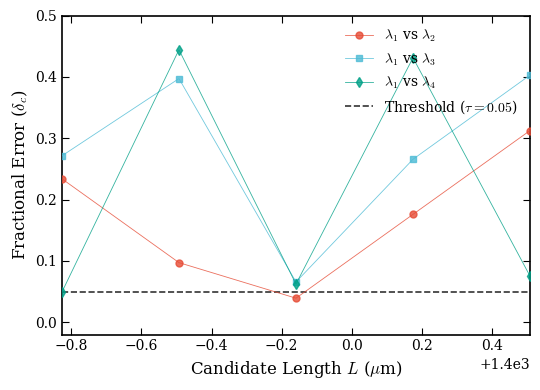

λ1 y λ2 -> L_real: 1399.84086098 um (Error: 0.0393)
Advertencia: Pobre coincidencia entre λ1 y λ3 (Error fraccional: 0.0657).
λ1 y λ4 -> L_real: 1399.17304258 um (Error: 0.0494)

Longitud Real Promedio: 1399.5070 um


In [ ]:
solver = ExcessFractionSolver(wavelengths=lambdas_nm, l_nominal=l_nom_nm, uncertainty_l=1e3)
solver.plot_error_valley(excess_fractions=fractions_measured, reference_wavelength=0, coincidence_threshold=0.05)

final_length = solver.calculate_real_length(excess_fractions=fractions_measured, reference_wavelength=0)

if final_length:
  print(f"\nLongitud Real Promedio: {final_length:.4f} um")
else:
  print("\nNo se pudo determinar una longitud confiable con el umbral dado.")

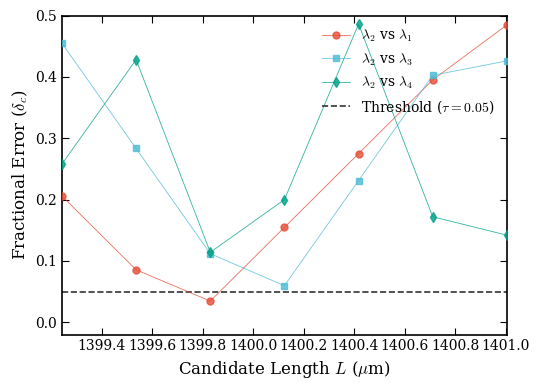

λ2 y λ1 -> L_real: 1399.82930688 um (Error: 0.0346)
Advertencia: Pobre coincidencia entre λ2 y λ3 (Error fraccional: 0.0596).
Advertencia: Pobre coincidencia entre λ2 y λ4 (Error fraccional: 0.1141).

Longitud Real Promedio: 1399.8293 um


In [ ]:
solver = ExcessFractionSolver(wavelengths=lambdas_nm, l_nominal=l_nom_nm, uncertainty_l=1e3)
solver.plot_error_valley(excess_fractions=fractions_measured, reference_wavelength=1, coincidence_threshold=0.05)
final_length = solver.calculate_real_length(excess_fractions=fractions_measured, reference_wavelength=1)

if final_length:
  print(f"\nLongitud Real Promedio: {final_length:.4f} um")
else:
  print("\nNo se pudo determinar una longitud confiable con el umbral dado.")

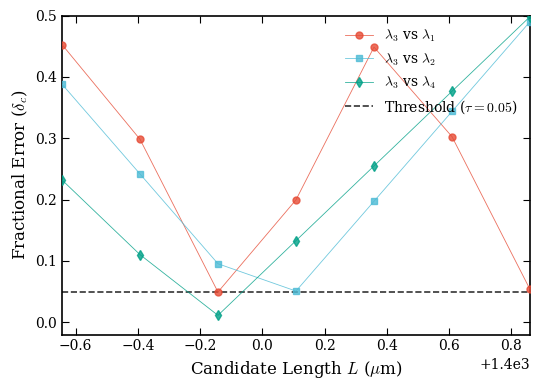

λ3 y λ1 -> L_real: 1399.85734969 um (Error: 0.0494)
Advertencia: Pobre coincidencia entre λ3 y λ2 (Error fraccional: 0.0509).
λ3 y λ4 -> L_real: 1399.85734969 um (Error: 0.0114)

Longitud Real Promedio: 1399.8573 um


In [ ]:
solver = ExcessFractionSolver(wavelengths=lambdas_nm, l_nominal=l_nom_nm, uncertainty_l=1e3)
solver.plot_error_valley(excess_fractions=fractions_measured, reference_wavelength=2, coincidence_threshold=0.05)
final_length = solver.calculate_real_length(excess_fractions=fractions_measured, reference_wavelength=2)

if final_length:
  print(f"\nLongitud Real Promedio: {final_length:.4f} um")
else:
  print("\nNo se pudo determinar una longitud confiable con el umbral dado.")

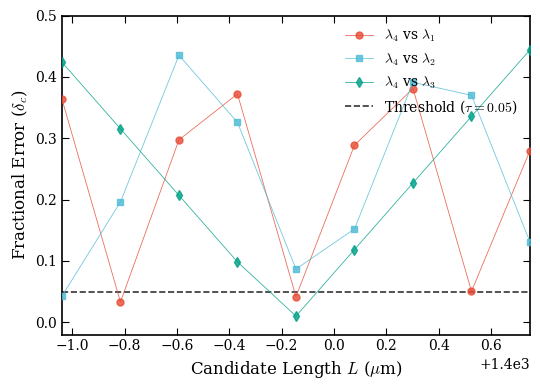

λ4 y λ1 -> L_real: 1399.18408516 um (Error: 0.0331)
λ4 y λ2 -> L_real: 1398.96051011 um (Error: 0.0427)
λ4 y λ3 -> L_real: 1399.85481031 um (Error: 0.0101)

Longitud Real Promedio: 1399.3331 um


In [ ]:
solver = ExcessFractionSolver(wavelengths=lambdas_nm, l_nominal=l_nom_nm, uncertainty_l=1e3)
solver.plot_error_valley(excess_fractions=fractions_measured, reference_wavelength=3, coincidence_threshold=0.05)
final_length = solver.calculate_real_length(excess_fractions=fractions_measured, reference_wavelength=3)

if final_length:
  print(f"\nLongitud Real Promedio: {final_length:.4f} um")
else:
  print("\nNo se pudo determinar una longitud confiable con el umbral dado.")

# Paper de Decker

In [ ]:


def metodo_fracciones_exceso(longitud_nominal_mm, longitudes_onda_nm, fracciones_medidas, tolerancia_um=10):
    """
    Calcula la longitud real de un bloque patrón minimizando los residuales de las fracciones.
    """

    L_nom_nm = longitud_nominal_mm * 1e6
    tolerancia_nm = tolerancia_um * 1000

    # 1. Definir la longitud de onda de referencia (láser He-Ne ~633 nm)
    lambda_ref = longitudes_onda_nm[0]
    F_ref = fracciones_medidas[0]

    m_inicial = int(2 * L_nom_nm / lambda_ref)

    rango_m = int(2 * tolerancia_nm / lambda_ref) + 1
    ordenes_m_prueba = np.arange(m_inicial - rango_m, m_inicial + rango_m + 1)

    mejor_longitud = 0
    menor_error = float('inf')

    for k in ordenes_m_prueba:
        L_test = (k + F_ref) * (lambda_ref / 2)

        error_total = 0
        for i in range(1, len(longitudes_onda_nm)):
            lambda_i = longitudes_onda_nm[i]
            F_medida = fracciones_medidas[i]

            F_teorica = (2 * L_test / lambda_i) % 1

            diff = abs(F_medida - F_teorica)
            diff = min(diff, 1 - diff)

            # Suma de cuadrados de los residuales
            error_total += diff**2

        # El orden k que minimice el error dictará la longitud óptima
        if error_total < menor_error:
            menor_error = error_total
            mejor_longitud = L_test

    # Retornar el valor absoluto calibrado en milímetros
    return mejor_longitud / 1e3

In [ ]:

# ==========================================
# Ejemplo de uso con los valores del paper
# ==========================================
# Láser He-Ne, Lámpara Cd roja, Cd verde, Cd azul (de la Tabla 1)
longitudes_onda = np.array([632.991162, 644.02480, 508.72379, 480.12521])
L_nominal = 100.0 # Bloque nominal de 100 mm

# Simulando fracciones leídas en el interferómetro para un bloque con +150 nm de desviación
L_real_simulada = 100.000150 * 1e6
fracciones_lectura = (2 * L_real_simulada / longitudes_onda) % 1

longitud_calibrada = metodo_fracciones_exceso(L_nominal, longitudes_onda, fracciones_lectura)
desviacion_nm = (longitud_calibrada - L_nominal) * 1e6

print(f"Longitud óptima ajustada: {longitud_calibrada:.6f} mm")
print(f"Desviación calculada (d): {desviacion_nm:.1f} nm")

Longitud óptima ajustada: 100000.150000 mm
Desviación calculada (d): 99900150000.0 nm


In [ ]:
longitudes_onda = np.array([667.8184, 587.5649, 501.5702, 447.1501])
L_nominal = 1.4  # [mm] 1400 um
fractions_measured = [0.28, 0.85, 0.90, 0.23]

longitud_calibrada = metodo_fracciones_exceso(L_nominal, longitudes_onda, fractions_measured)
desviacion_nm = (longitud_calibrada - L_nominal)

print(f"Longitud óptima ajustada: {longitud_calibrada:.6f} um")
print(f"Desviación calculada (d): {desviacion_nm:.1f} um")


Longitud óptima ajustada: 1399.840861 um
Desviación calculada (d): 1398.4 um


In [ ]:
longitud_calibrada

np.float64(1399.840860976)